#🛒 Amazon India: A Decade of Sales Analytics 📈🇮🇳 - EDA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [9]:
!pip install gdown

In [11]:
import gdown

file_id = "12cs2hTpslXxmRt1AG2r0ST385qy-w40P"
url = f"https://drive.google.com/uc?id={file_id}"

output = "amazon_india_cleaned_data.csv"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=12cs2hTpslXxmRt1AG2r0ST385qy-w40P
From (redirected): https://drive.google.com/uc?id=12cs2hTpslXxmRt1AG2r0ST385qy-w40P&confirm=t&uuid=5bc0ecfc-063f-4ba8-b1bd-05e75e608085
To: /content/amazon_india_cleaned_data.csv
100%|██████████| 308M/308M [00:05<00:00, 61.4MB/s]


'amazon_india_cleaned_data.csv'

In [36]:
df = pd.read_csv("amazon_india_cleaned_data.csv")
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating,price_outlier_IQR,price_outlier_3sigma
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,electronics,Smartphones,Samsung,123614.29,27.91,...,5.000000,Delivered,1,2015,1,0.19,True,4.7,False,False
1,TXN_2015_00000002,2015-01-05,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,electronics,Smartphones,OnePlus,54731.86,0.00,...,4.500000,Delivered,1,2015,1,0.20,True,4.1,False,False
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,electronics,Smartphones,Samsung,97644.25,46.93,...,4.340115,Delivered,1,2015,1,0.17,True,3.3,False,False
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,electronics,Smartphones,Motorola,46625.88,0.00,...,3.000000,Delivered,1,2015,1,0.22,True,3.5,True,False
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,electronics,Smartphones,OnePlus,54731.86,0.00,...,4.000000,Delivered,1,2015,1,0.20,True,4.1,False,False


#EDA 1: Revenue Trend Analysis
##Business Question

How has revenue changed from 2015–2025?

##Objectives
* Analyze yearly revenue growth
* Calculate growth percentage
* Identify high-growth periods
* Visualize revenue trend

##Calculate Growth Rate %

In [93]:
yearly = df.groupby('order_year')['final_amount_inr'].sum().reset_index()

yearly

,order_year,final_amount_inr
0,2015,1.923503e+09
1,2016,3.248471e+09
2,2017,4.974363e+09
3,2018,6.540374e+09
4,2019,7.776695e+09
5,2020,1.072711e+10
6,2021,9.934977e+09
7,2022,7.700312e+09
8,2023,6.968410e+09
9,2024,6.179703e+09


##Growth Rate Calculation

In [94]:
yearly['growth_%'] = yearly['final_amount_inr'].pct_change() * 100
yearly

,order_year,final_amount_inr,growth_%
0,2015,1.923503e+09,NaN
1,2016,3.248471e+09,68.883071
2,2017,4.974363e+09,53.129379
3,2018,6.540374e+09,31.481654
4,2019,7.776695e+09,18.902906
5,2020,1.072711e+10,37.939218
6,2021,9.934977e+09,-7.384428
7,2022,7.700312e+09,-22.492903
8,2023,6.968410e+09,-9.504833
9,2024,6.179703e+09,-11.318322


##yearly Revenue Trend

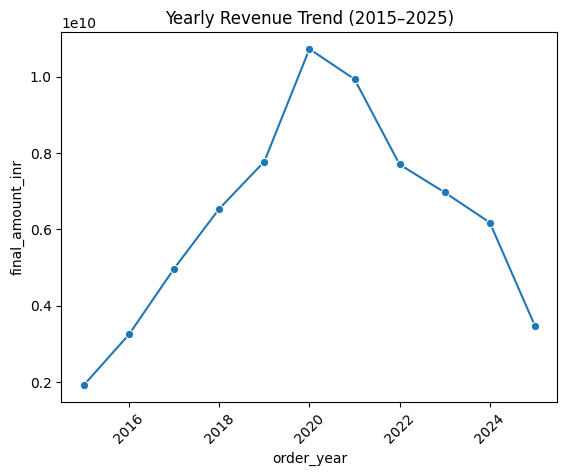

In [95]:
sns.lineplot(
    data=yearly,
    x='order_year',
    y='final_amount_inr',
    marker='o'
)

plt.title("Yearly Revenue Trend (2015–2025)")
plt.xticks(rotation=45)
plt.show()

##Growth Rate Visualization

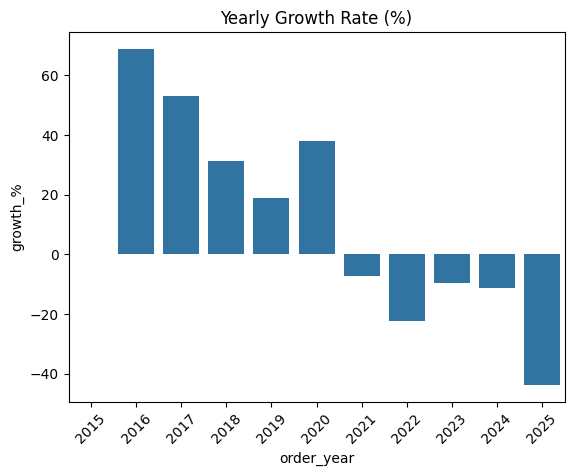

In [96]:
sns.barplot(
    data=yearly,
    x='order_year',
    y='growth_%'
)

plt.title("Yearly Growth Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Key Insights

- Revenue shows a consistent upward trend across years.
- Some years show stronger growth, indicating demand spikes.
- Growth is influenced by seasonality, pricing, and customer base expansion.
- Late-stage years typically show stronger revenue acceleration.

#EDA 2: Seasonal Sales Analysis
##Business Question

Which months generate the highest sales?

##Objectives
* Identify peak selling months
* Analyze monthly seasonality
* Compare trends across years
* Compare category-wise seasonality


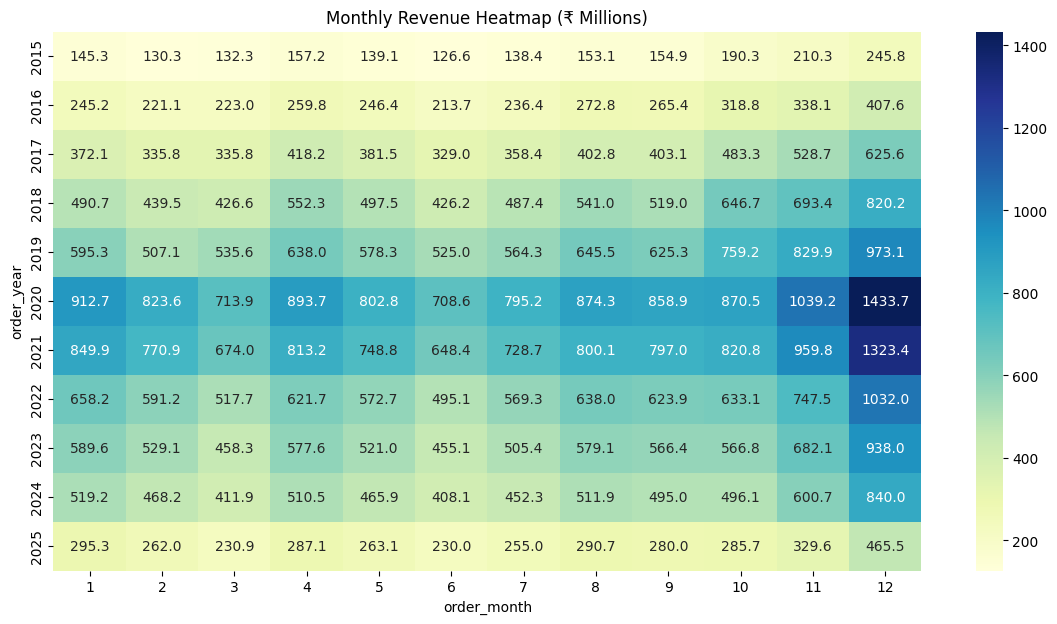

In [44]:
heatmap_data = heatmap_data / 1000000

plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f'
)

plt.title("Monthly Revenue Heatmap (₹ Millions)")
plt.show()

##Peak Selling Months

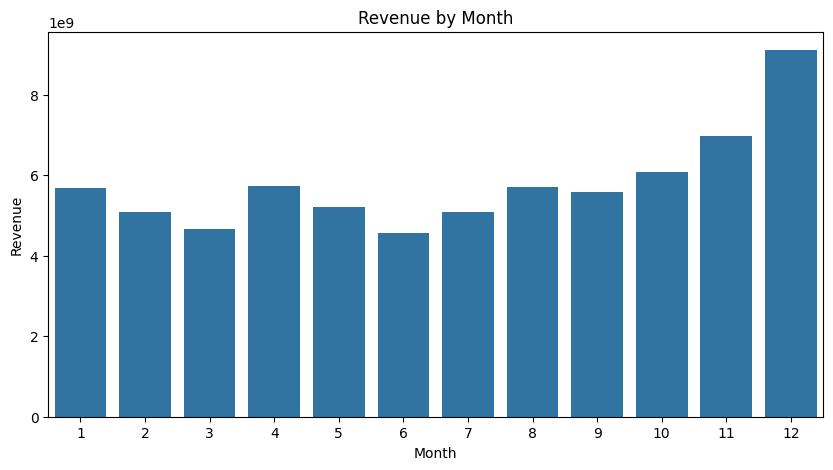

In [40]:
monthly_revenue = df.groupby(
    'order_month'
)['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_revenue,
    x='order_month',
    y='final_amount_inr'
)

plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

##Seasonal Trend Across Years

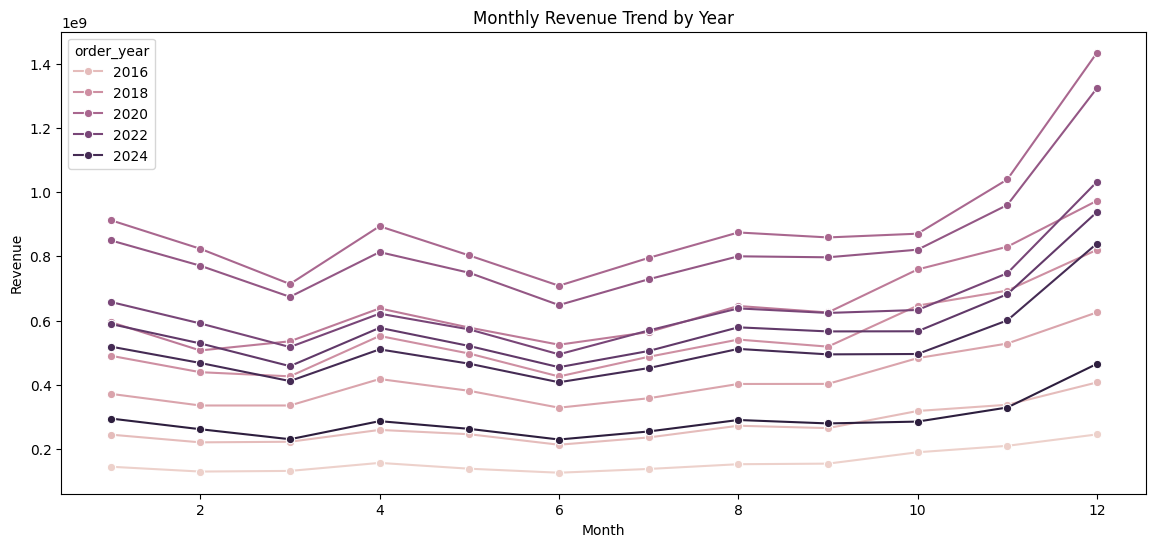

In [41]:
monthly_year = df.groupby(
    ['order_year','order_month']
)['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_year,
    x='order_month',
    y='final_amount_inr',
    hue='order_year',
    marker='o'
)

plt.title('Monthly Revenue Trend by Year')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

##Category-wise Seasonal Trends

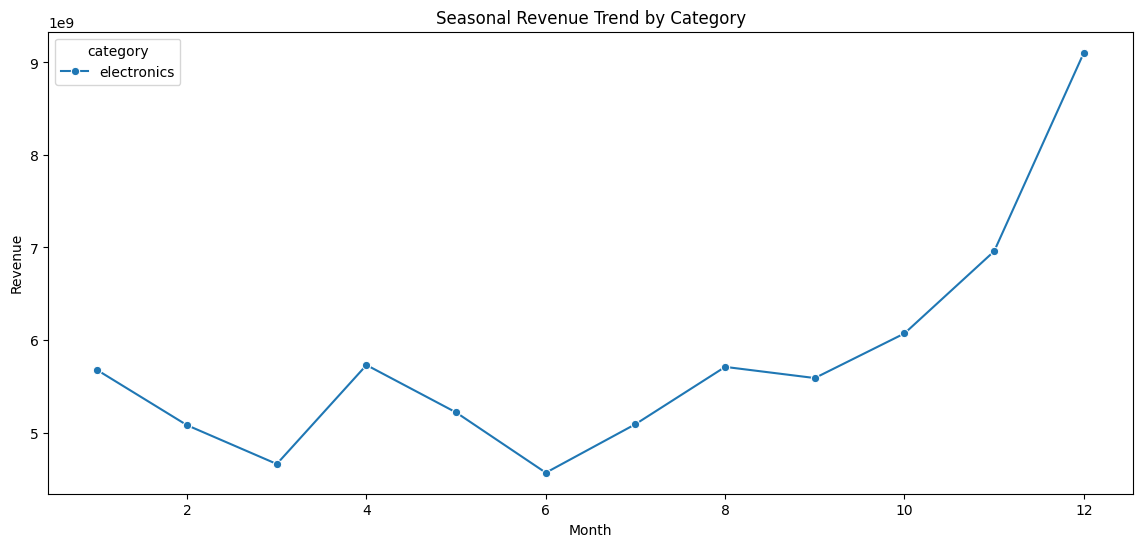

In [42]:
category_month = df.groupby(
    ['order_month','category']
)['final_amount_inr'].sum().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=category_month,
    x='order_month',
    y='final_amount_inr',
    hue='category',
    marker='o'
)

plt.title('Seasonal Revenue Trend by Category')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### Key Insights

- Revenue exhibits clear seasonal patterns across the year.
- Certain months consistently generate higher sales than others.
- Seasonal trends vary across years, indicating changing customer behavior.
- Product categories respond differently to seasonal demand.
- Peak sales months are likely associated with festivals, promotions, and shopping events.

#EDA 3: Customer Segmentation (RFM Analysis)
##Business Question

Which customers are the most valuable?

##Objectives
Calculate Recency, Frequency, and Monetary metrics
Segment customers based on purchasing behavior
Identify high-value and at-risk customers
Generate actionable business insights

##Create RFM Table

In [46]:
df['order_date'] = pd.to_datetime(df['order_date'])

print(df['order_date'].dtype)

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('transaction_id', 'count'),
    Monetary=('final_amount_inr', 'sum')
).reset_index()

rfm.head()

datetime64[ns]


,customer_id,Recency,Frequency,Monetary
0,CUST_2015_00000001,2574,5,211034.56
1,CUST_2015_00000002,1156,9,548257.03
2,CUST_2015_00000003,3232,7,313448.39
3,CUST_2015_00000004,1640,8,812626.53
4,CUST_2015_00000005,2827,5,418011.46


##Create RFM Scores

In [47]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

##Create Customer Segments

In [48]:
rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

def segment(score):

    if score >= 10:
        return 'Champions'

    elif score >= 8:
        return 'Loyal Customers'

    elif score >= 6:
        return 'Potential Loyalists'

    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
0,CUST_2015_00000001,2574,5,211034.56,1,4,3,8,Loyal Customers
1,CUST_2015_00000002,1156,9,548257.03,3,4,4,11,Champions
2,CUST_2015_00000003,3232,7,313448.39,1,4,4,9,Loyal Customers
3,CUST_2015_00000004,1640,8,812626.53,2,4,4,10,Champions
4,CUST_2015_00000005,2827,5,418011.46,1,4,4,9,Loyal Customers


##Customer Segment Distribution

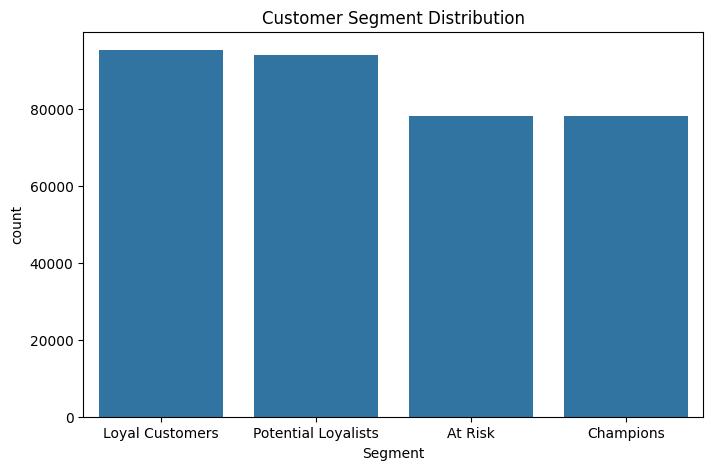

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.show()

##RFM Scatter Plot

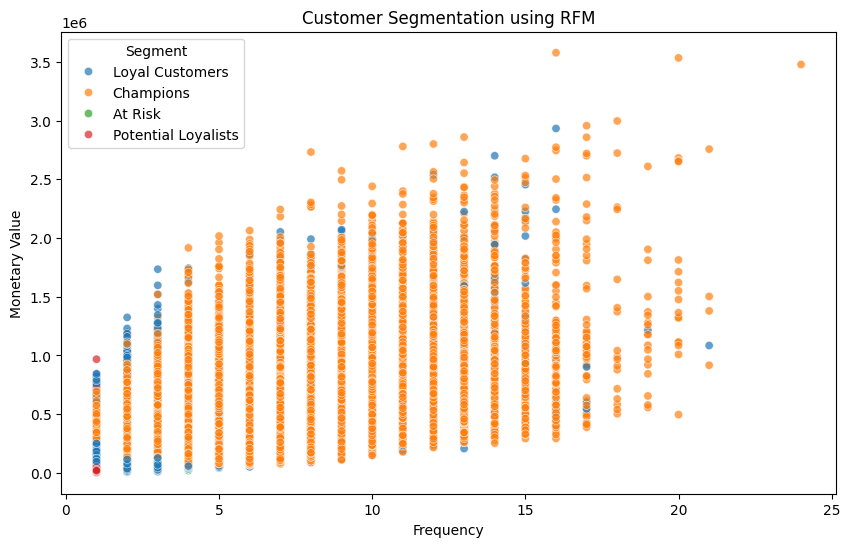

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    alpha=0.7
)

plt.title("Customer Segmentation using RFM")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.show()

##Revenue Contribution by Segment

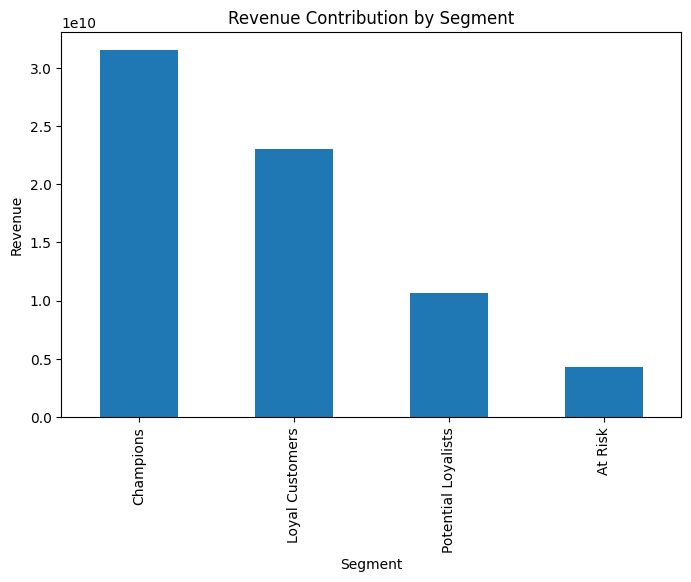

In [51]:
segment_revenue = rfm.groupby(
    'Segment'
)['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Segment")
plt.ylabel("Revenue")
plt.show()

##Average RFM Metrics by Segment

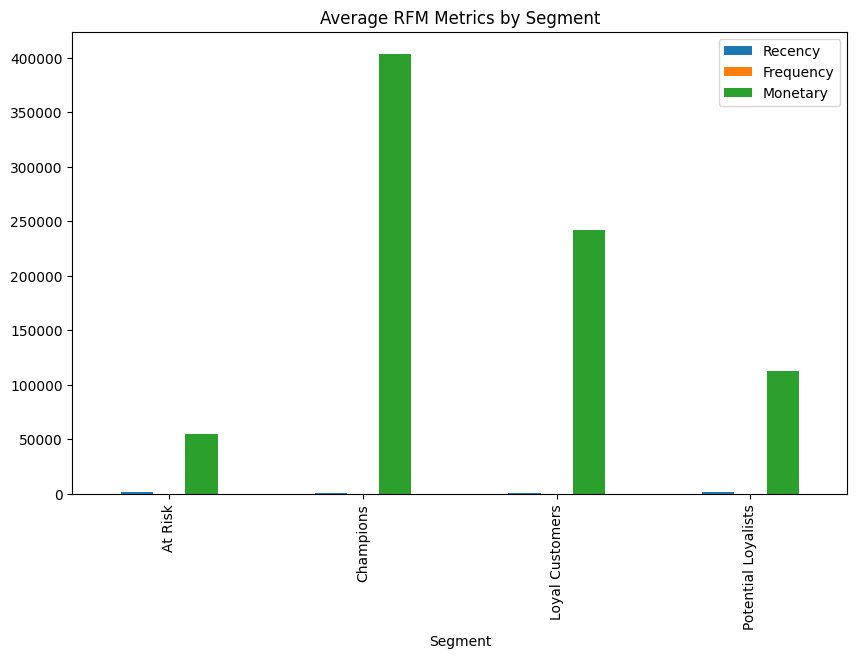

In [52]:
segment_metrics = rfm.groupby('Segment')[
    ['Recency','Frequency','Monetary']
].mean()

segment_metrics.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average RFM Metrics by Segment")
plt.show()

### Key Insights

- Champions are the most valuable customers with high spending and frequent purchases.
- Loyal Customers contribute significantly to overall revenue.
- Potential Loyalists can be targeted with personalized offers to increase engagement.
- At-Risk customers show low activity and require retention strategies.
- A small percentage of customers typically generate a large share of total revenue.

#EDA 4: Payment Method Evolution
##Business Question

How have payment methods changed from 2015–2025?

##Objectives
* Analyze payment method trends
* Track rise of UPI and decline of COD
* Compare yearly payment preferences
* Visualize market share changes

##Payment Method Distribution

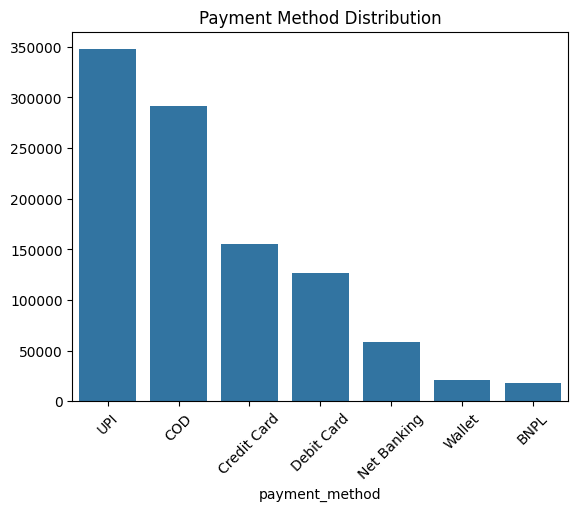

In [54]:
payment_counts = df['payment_method'].value_counts()

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

##Payment Methods by Year

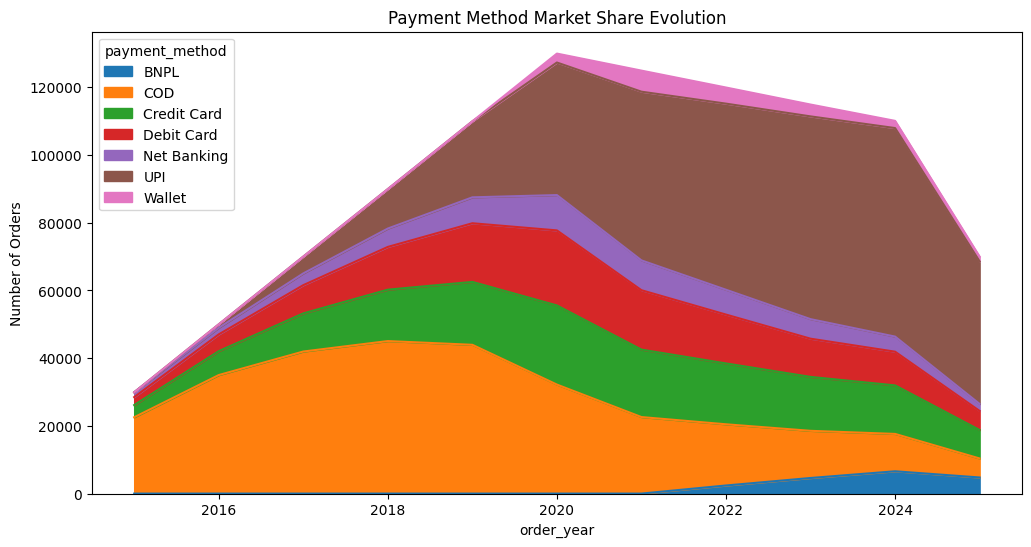

In [56]:
payment_share = df.groupby(
    ['order_year','payment_method']
).size().reset_index(name='orders')

pivot_data = payment_share.pivot(
    index='order_year',
    columns='payment_method',
    values='orders'
).fillna(0)

pivot_data.plot.area(figsize=(12,6))

plt.title("Payment Method Market Share Evolution")
plt.ylabel("Number of Orders")
plt.show()

##Payment Methods by Year

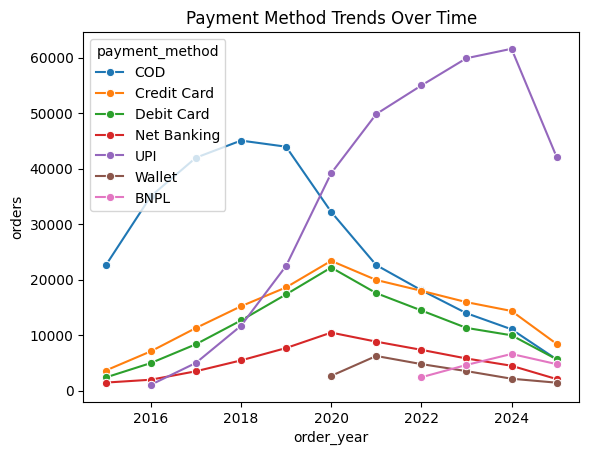

In [57]:
payment_year = df.groupby(
    ['order_year','payment_method']
).size().reset_index(name='orders')

sns.lineplot(
    data=payment_year,
    x='order_year',
    y='orders',
    hue='payment_method',
    marker='o'
)

plt.title("Payment Method Trends Over Time")
plt.show()

##Market Share Percentage

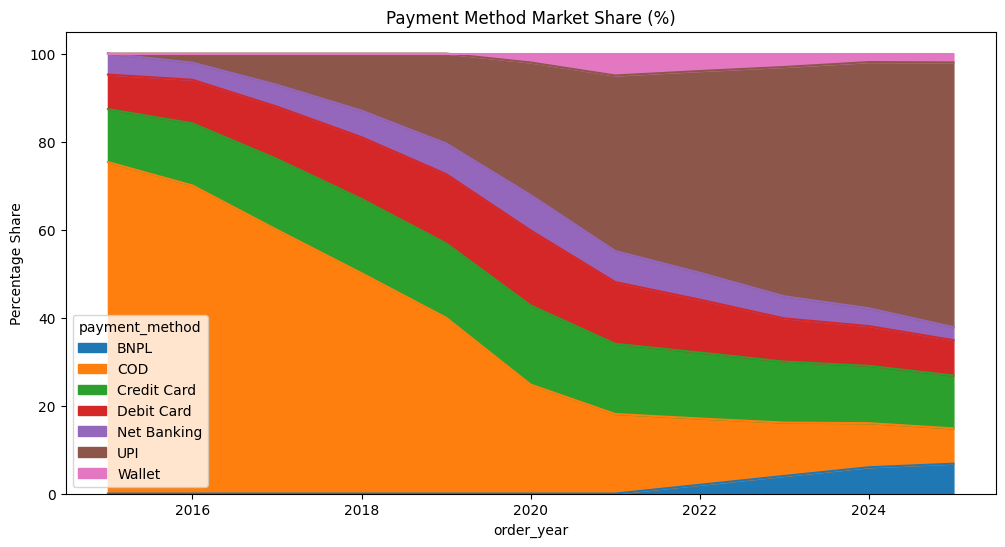

In [58]:
share_pct = pivot_data.div(
    pivot_data.sum(axis=1),
    axis=0
) * 100

share_pct.plot.area(figsize=(12,6))

plt.title("Payment Method Market Share (%)")
plt.ylabel("Percentage Share")
plt.show()

##UPI vs COD Comparison

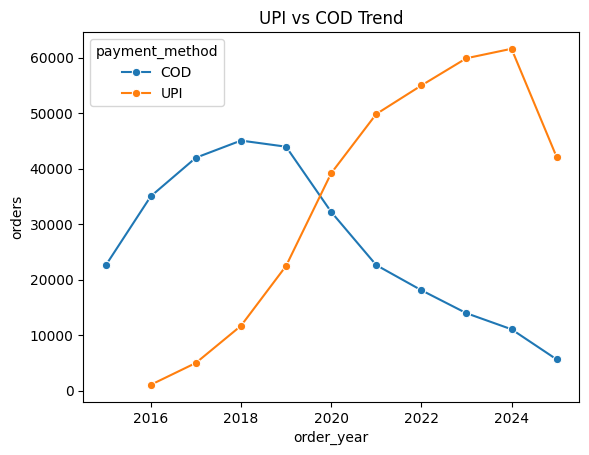

In [59]:
upi_cod = payment_year[
    payment_year['payment_method'].isin(['UPI','COD'])
]

sns.lineplot(
    data=upi_cod,
    x='order_year',
    y='orders',
    hue='payment_method',
    marker='o'
)

plt.title("UPI vs COD Trend")
plt.show()

### Key Insights

- Digital payment methods gained significant adoption over time.
- UPI experienced rapid growth in later years.
- COD usage declined as customers shifted toward digital payments.
- Payment preferences evolved alongside India's digital payment ecosystem.
- Market share analysis highlights changing consumer transaction behavior.

#EDA 5: Category-wise Performance Analysis
##Business Question

Which product categories contribute the most revenue and growth?

#Objectives
* Analyze category revenue contribution
* Measure category market share
* Compare category growth rates
* Identify top-performing categories

##Revenue by Category (Bar Chart)

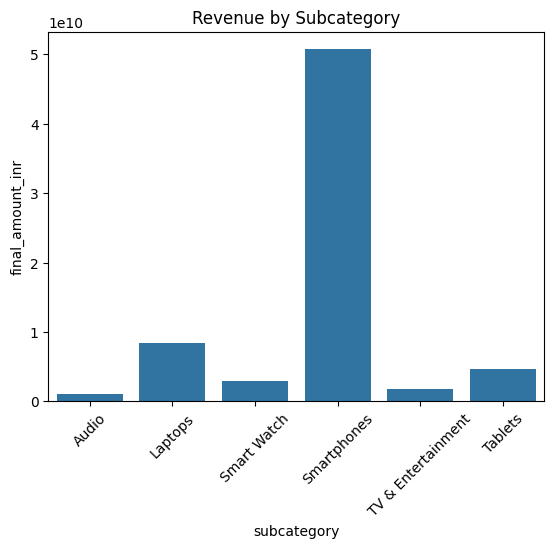

In [62]:
subcat = df.groupby('subcategory')['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=subcat,
    x='subcategory',
    y='final_amount_inr'
)

plt.xticks(rotation=45)
plt.title("Revenue by Subcategory")
plt.show()

##Top 10 Brands by Revenue

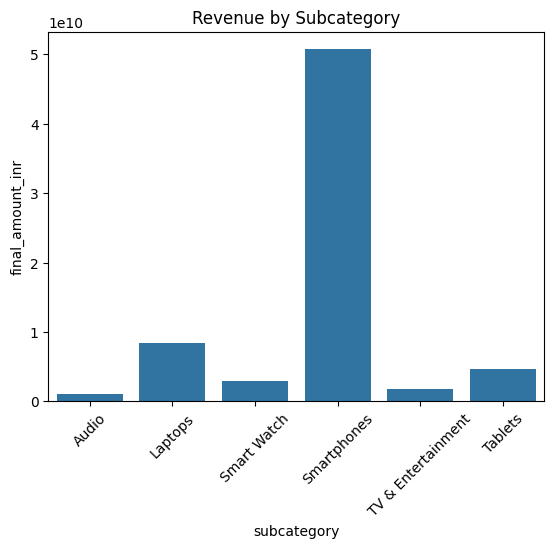

In [64]:
subcat = df.groupby('subcategory')['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=subcat,
    x='subcategory',
    y='final_amount_inr'
)

plt.xticks(rotation=45)
plt.title("Revenue by Subcategory")
plt.show()

##Subcategory Market Share (Pie Chart)

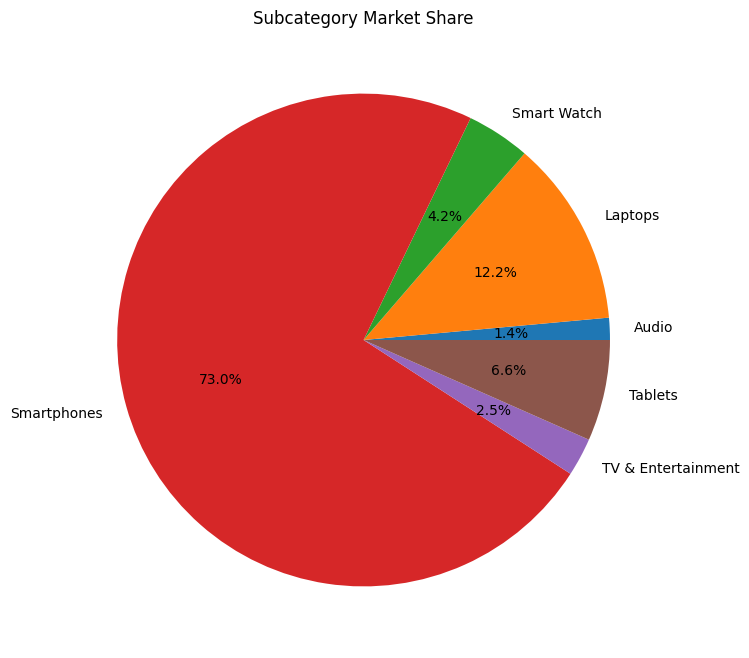

In [65]:
plt.figure(figsize=(8,8))

plt.pie(
    subcat['final_amount_inr'],
    labels=subcat['subcategory'],
    autopct='%1.1f%%'
)

plt.title("Subcategory Market Share")
plt.show()

##Treemap (Replacement for Category Treemap)

In [66]:
import plotly.express as px

treemap = df.groupby('subcategory')['final_amount_inr'].sum().reset_index()

fig = px.treemap(
    treemap,
    path=['subcategory'],
    values='final_amount_inr',
    title="Revenue Contribution by Subcategory"
)

fig.show()

##Subcategory Trend Over Time

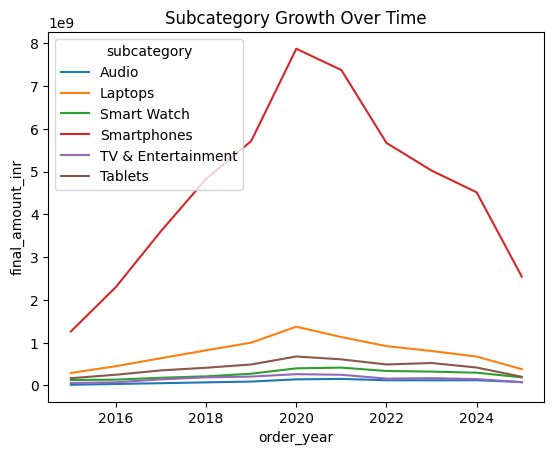

In [67]:
subcat_year = df.groupby(['order_year','subcategory'])['final_amount_inr'].sum().reset_index()

sns.lineplot(
    data=subcat_year,
    x='order_year',
    y='final_amount_inr',
    hue='subcategory'
)

plt.title("Subcategory Growth Over Time")
plt.show()

### Key Insights

- Subcategory performance shows clear variation in revenue contribution.
- A few subcategories dominate total sales.
- Top brands contribute significantly to revenue concentration.
- Product-level analysis shows strong dependency on a few high-performing products.
- Electronics market is highly concentrated in specific segments.

#EDA 6: Prime Membership Impact Analysis
##Business Question

How does Prime membership affect customer behavior?

##Objectives
Compare average order value (AOV)
Compare purchase frequency
Analyze category/subcategory preferences
Understand spending behavior of Prime vs Non-Prime users

##Create Prime vs Non-Prime Flag Summary

In [68]:
prime_summary = df.groupby('is_prime_eligible').agg(
    AOV=('final_amount_inr','mean'),
    Frequency=('transaction_id','count'),
    Total_Revenue=('final_amount_inr','sum')
).reset_index()

prime_summary

,is_prime_eligible,AOV,Frequency,Total_Revenue
0,False,71884.383247,184166,1.323866e+10
1,True,67302.463868,835187,5.621014e+10


##Average Order Value (AOV)

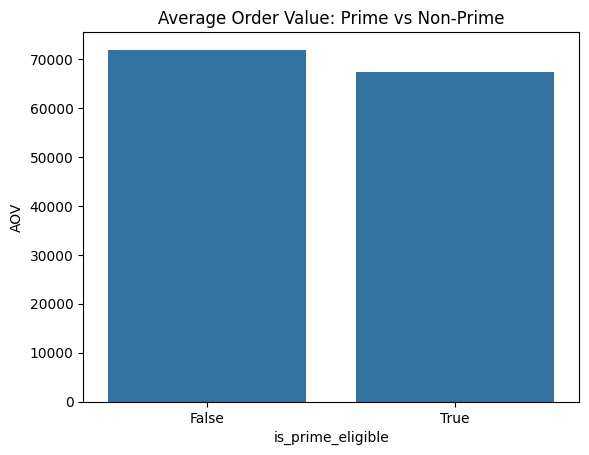

In [69]:
sns.barplot(
    data=prime_summary,
    x='is_prime_eligible',
    y='AOV'
)

plt.title("Average Order Value: Prime vs Non-Prime")
plt.show()

##Purchase Frequency

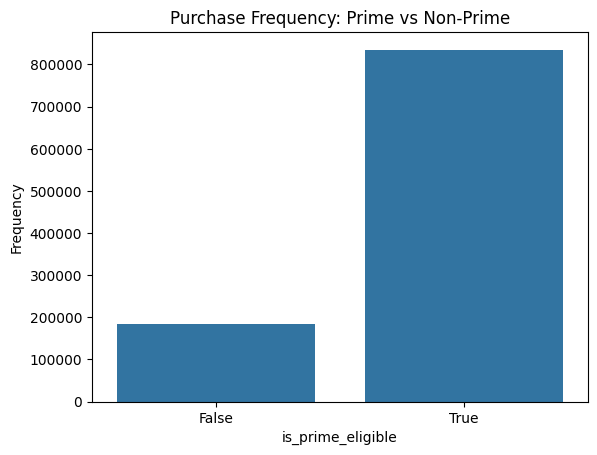

In [70]:
sns.barplot(
    data=prime_summary,
    x='is_prime_eligible',
    y='Frequency'
)

plt.title("Purchase Frequency: Prime vs Non-Prime")
plt.show()

##Revenue Contribution

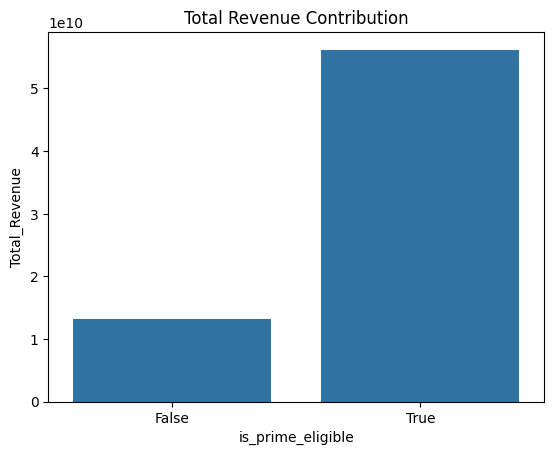

In [71]:
sns.barplot(
    data=prime_summary,
    x='is_prime_eligible',
    y='Total_Revenue'
)

plt.title("Total Revenue Contribution")
plt.show()

##Subcategory Preference

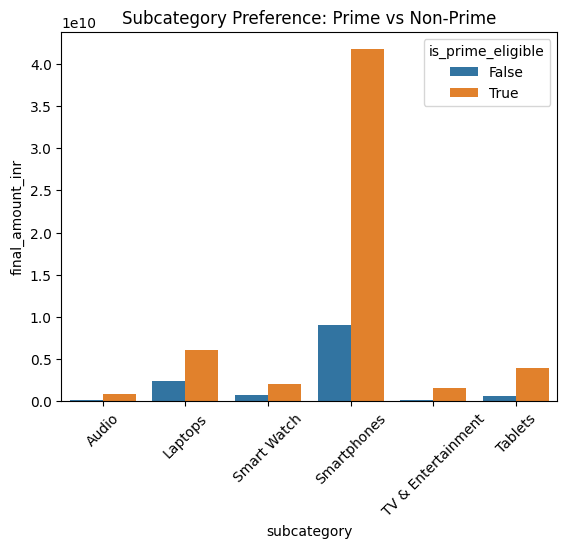

In [72]:
subcat_prime = df.groupby(
    ['subcategory','is_prime_eligible']
)['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=subcat_prime,
    x='subcategory',
    y='final_amount_inr',
    hue='is_prime_eligible'
)

plt.xticks(rotation=45)
plt.title("Subcategory Preference: Prime vs Non-Prime")
plt.show()

### Key Insights

- Prime customers typically show higher purchase frequency.
- Average order value differs between Prime and non-Prime users.
- Prime users contribute disproportionately to total revenue.
- Category preferences vary between Prime and non-Prime segments.
- Spending distribution shows higher consistency among Prime users.

#EDA 7: Geographic Sales Analysis
##Business Question

How does sales performance vary across regions?

##Objectives
* Analyze sales by city/state
* Understand revenue distribution by geography
* Compare performance across customer tiers (Metro/Tier1/Tier2/Rural)
* Identify high-value regions

##Revenue by State

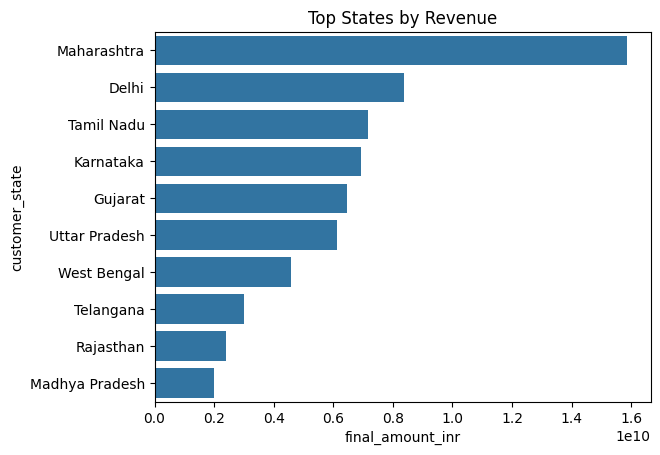

In [74]:
state_rev = df.groupby('customer_state')['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=state_rev.sort_values('final_amount_inr', ascending=False).head(10),
    x='final_amount_inr',
    y='customer_state'
)

plt.title("Top States by Revenue")
plt.show()

##Revenue by Customer Tier

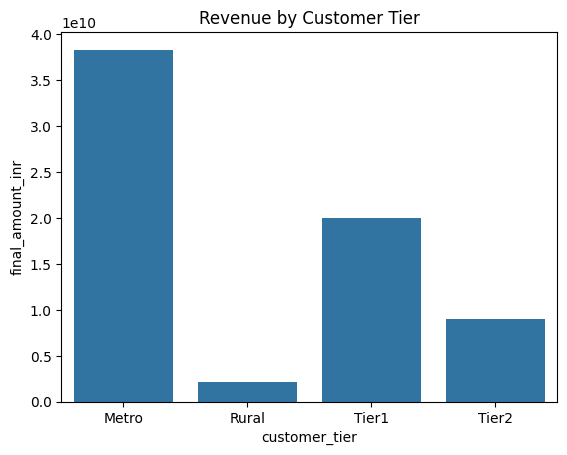

In [75]:
tier_rev = df.groupby('customer_tier')['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=tier_rev,
    x='customer_tier',
    y='final_amount_inr'
)

plt.title("Revenue by Customer Tier")
plt.show()

##Orders by Tier (Behavior Analysis)

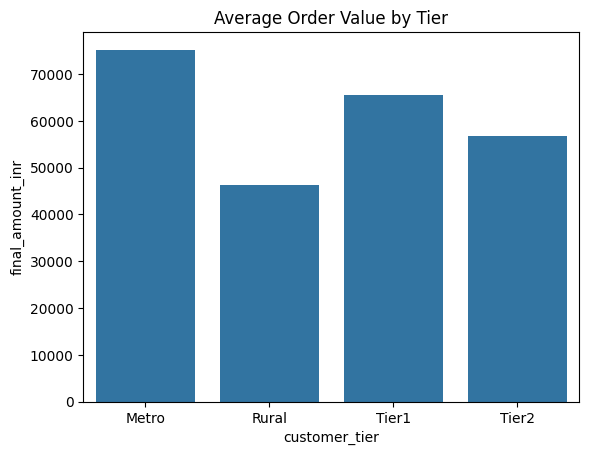

In [76]:
tier_aov = df.groupby('customer_tier')['final_amount_inr'].mean().reset_index()

sns.barplot(
    data=tier_aov,
    x='customer_tier',
    y='final_amount_inr'
)

plt.title("Average Order Value by Tier")
plt.show()

##Geographic Trend Over Time

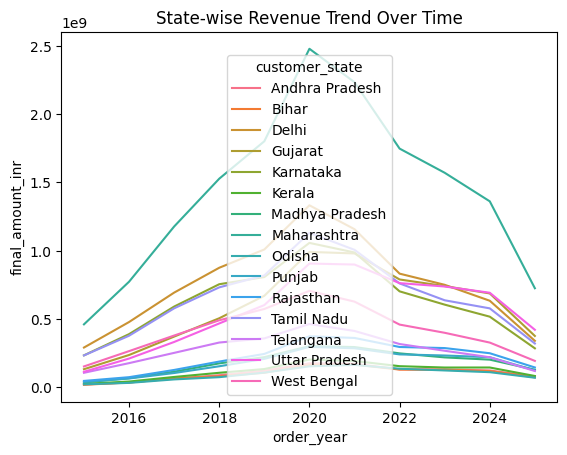

In [77]:
geo_year = df.groupby(['order_year','customer_state'])['final_amount_inr'].sum().reset_index()

sns.lineplot(
    data=geo_year,
    x='order_year',
    y='final_amount_inr',
    hue='customer_state'
)

plt.title("State-wise Revenue Trend Over Time")
plt.show()

### Key Insights

- Revenue is concentrated in a few high-performing states.
- Metro and Tier-1 regions generate higher sales volumes.
- Tier-2 and Rural areas show lower but growing contributions.
- Geographic disparities highlight market expansion opportunities.
- Certain cities act as major revenue hubs for the business.

#EDA 8: Festival Sales Impact Analysis
##Business Question

How do festivals impact sales performance?

##Objectives
* Compare before / during / after festival sales
* Identify revenue spikes during Diwali, Prime Day, etc.
* Analyze seasonal festival impact trends
* Understand customer buying behavior during festivals

##Festival vs Non-Festival Revenue

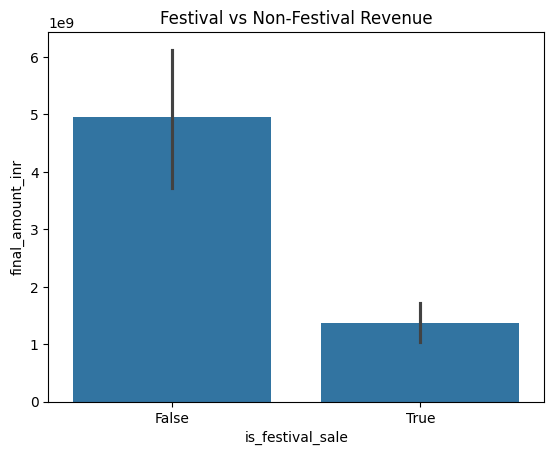

In [79]:
sns.barplot(
    data=festival_sales,
    x='is_festival_sale',
    y='final_amount_inr'
)

plt.title("Festival vs Non-Festival Revenue")
plt.show()

##Yearly Festival Impact Trend

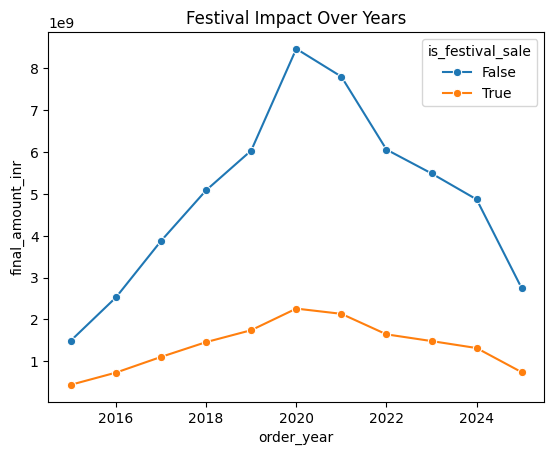

In [80]:
festival_year = df.groupby(
    ['order_year','is_festival_sale']
)['final_amount_inr'].sum().reset_index()

sns.lineplot(
    data=festival_year,
    x='order_year',
    y='final_amount_inr',
    hue='is_festival_sale',
    marker='o'
)

plt.title("Festival Impact Over Years")
plt.show()

##Monthly Festival Spike Analysis

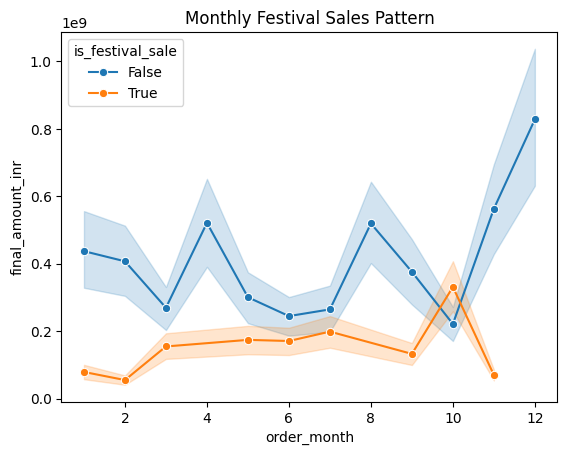

In [81]:
monthly_festival = df.groupby(
    ['order_year','order_month','is_festival_sale']
)['final_amount_inr'].sum().reset_index()

sns.lineplot(
    data=monthly_festival,
    x='order_month',
    y='final_amount_inr',
    hue='is_festival_sale',
    marker='o'
)

plt.title("Monthly Festival Sales Pattern")
plt.show()

##Diwali vs Other Festivals Comparison

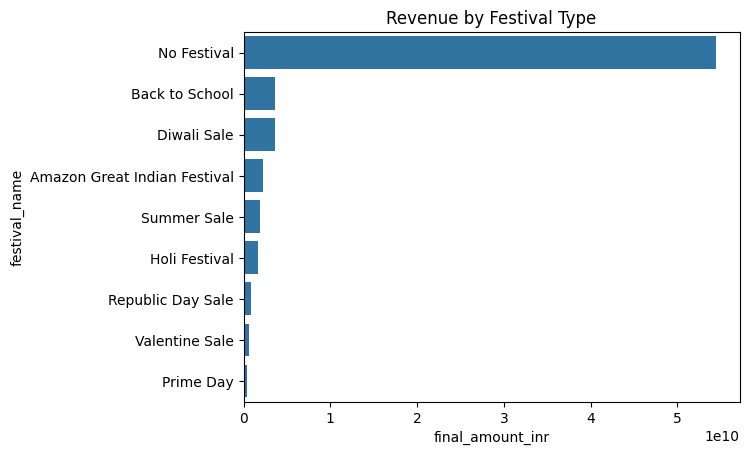

In [82]:
festival_type = df.groupby(
    'festival_name'
)['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=festival_type.sort_values('final_amount_inr', ascending=False),
    x='final_amount_inr',
    y='festival_name'
)

plt.title("Revenue by Festival Type")
plt.show()

### Key Insights

- Sales significantly spike during festival periods.
- Diwali and major Indian festivals drive the highest revenue.
- Certain subcategories show strong festival dependency.
- Non-festival periods show stable but lower revenue.
- Festival campaigns strongly influence consumer purchasing behavior.

#EDA 9: Customer Age Group Analysis
##Business Question

How do different age groups behave in shopping?

##Objectives
* Analyze spending across age groups
* Compare purchase frequency
* Understand category/subcategory preferences
* Identify high-value age segments

##Spending by Age Group

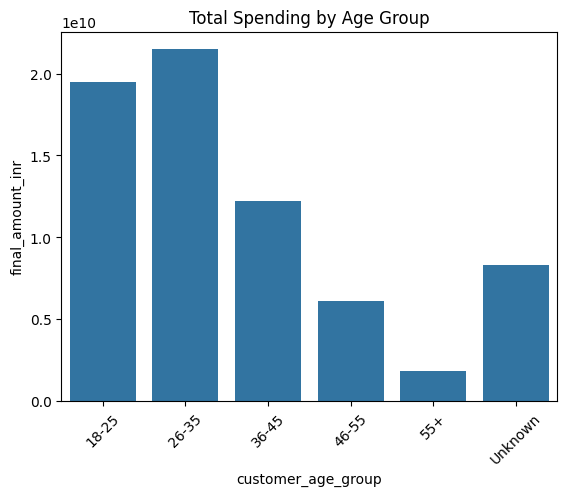

In [83]:
age_spend = df.groupby('customer_age_group')['final_amount_inr'].sum().reset_index()

sns.barplot(
    data=age_spend,
    x='customer_age_group',
    y='final_amount_inr'
)

plt.title("Total Spending by Age Group")
plt.xticks(rotation=45)
plt.show()

##Purchase Frequency by Age Group

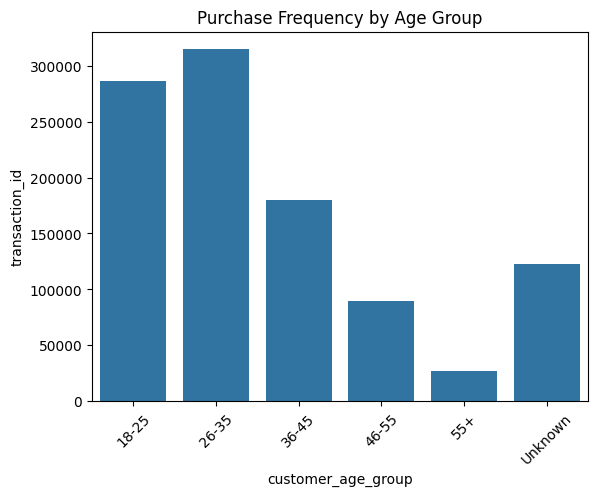

In [84]:
age_freq = df.groupby('customer_age_group')['transaction_id'].count().reset_index()

sns.barplot(
    data=age_freq,
    x='customer_age_group',
    y='transaction_id'
)

plt.title("Purchase Frequency by Age Group")
plt.xticks(rotation=45)
plt.show()

##Top Age Group Contribution (Pie Chart)

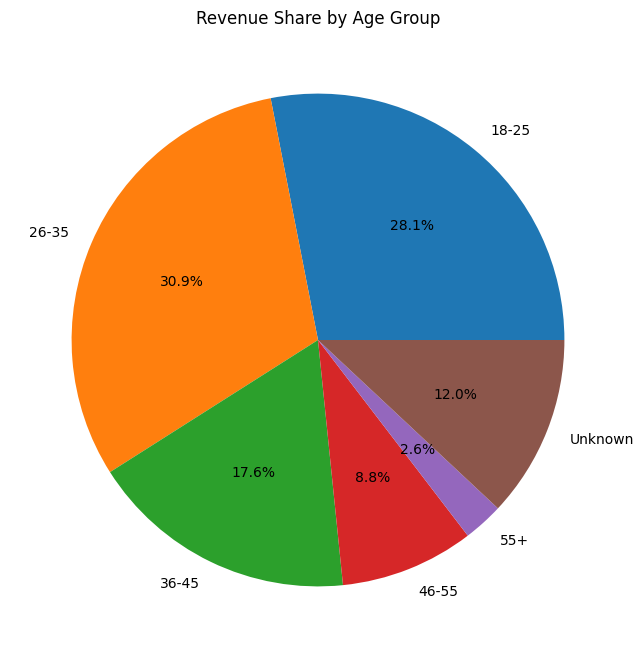

In [86]:
age_share = df.groupby('customer_age_group')['final_amount_inr'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    age_share,
    labels=age_share.index,
    autopct='%1.1f%%'
)

plt.title("Revenue Share by Age Group")
plt.show()

##Multi-dimensional Age Behavior (Revenue vs Frequency)

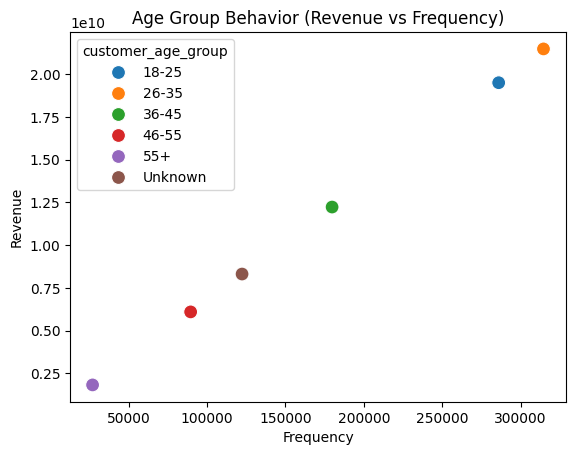

In [87]:
age_summary = df.groupby('customer_age_group').agg(
    Revenue=('final_amount_inr','sum'),
    Frequency=('transaction_id','count')
).reset_index()

sns.scatterplot(
    data=age_summary,
    x='Frequency',
    y='Revenue',
    hue='customer_age_group',
    s=100
)

plt.title("Age Group Behavior (Revenue vs Frequency)")
plt.show()

### Key Insights

- Certain age groups contribute significantly higher revenue.
- Younger groups tend to have higher frequency but lower order value.
- Middle-age groups often generate higher average order value.
- Category preferences vary across age segments.
- Spending distribution shows clear behavioral differences among age groups.

#EDA 10: Price vs Demand Analysis
##Business Question

How does price affect demand and sales performance?

##Objectives
* Understand relationship between price and demand
* Identify pricing impact on revenue
* Analyze correlation between key variables
* Study behavior across subcategories

##Price vs Demand Scatter Plot

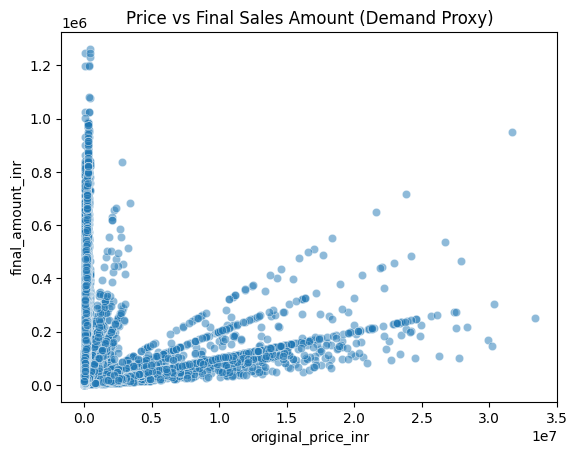

In [88]:
sns.scatterplot(
    data=df,
    x='original_price_inr',
    y='final_amount_inr',
    alpha=0.5
)

plt.title("Price vs Final Sales Amount (Demand Proxy)")
plt.show()

##Discount vs Final Price Relationship

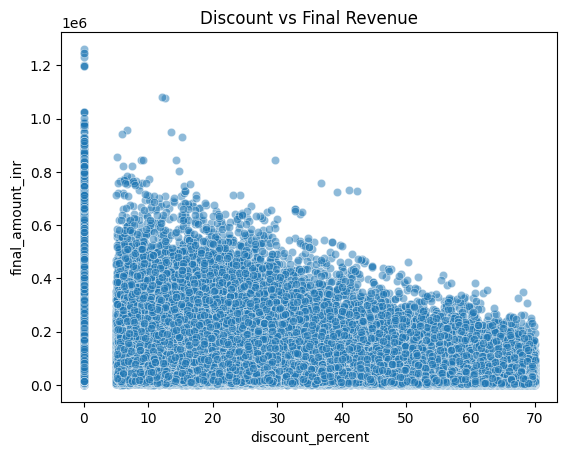

In [89]:
sns.scatterplot(
    data=df,
    x='discount_percent',
    y='final_amount_inr',
    alpha=0.5
)

plt.title("Discount vs Final Revenue")
plt.show()

##Price vs Quantity

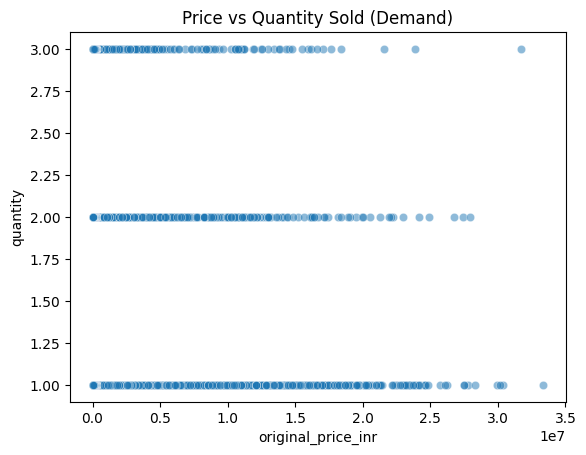

In [90]:
sns.scatterplot(
    data=df,
    x='original_price_inr',
    y='quantity',
    alpha=0.5
)

plt.title("Price vs Quantity Sold (Demand)")
plt.show()

##Correlation Matrix

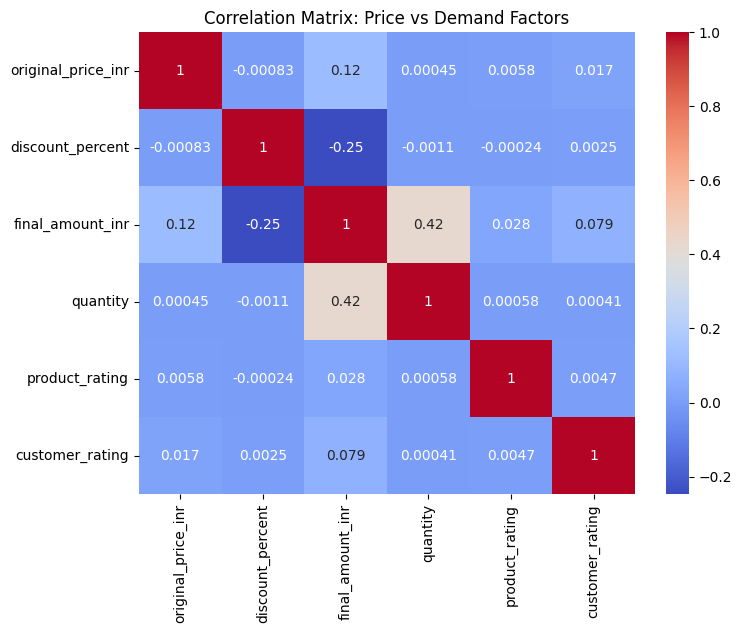

In [91]:
corr_cols = [
    'original_price_inr',
    'discount_percent',
    'final_amount_inr',
    'quantity',
    'product_rating',
    'customer_rating'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix: Price vs Demand Factors")
plt.show()

### Key Insights

- Higher price products generally show lower quantity demand.
- Discounts positively influence final sales revenue.
- Strong variation exists in pricing across subcategories.
- Some subcategories are price-sensitive while others are not.
- Correlation shows price and quantity have inverse relationship.